In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [4]:
df = pd.read_csv(r'C:\Users\Егор\Desktop\fewfer\UDGU_project-master\clearing_df.csv')

In [5]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

predictions = model.predict(X_test)
y_pred = model.predict(X_test)         
y_proba = model.predict_proba(X_test)   

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.31%


Accuracy:0.923
Precision:1.000
Recall:  0.875
F1-score: 0.933

Confusion Matrix:
 [[5 0]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.88      0.93         8

    accuracy                           0.92        13
   macro avg       0.92      0.94      0.92        13
weighted avg       0.94      0.92      0.92        13

F1-результаты по фолдам: [1.         1.         0.66666667 1.         0.        ]
Средний F1: 0.73


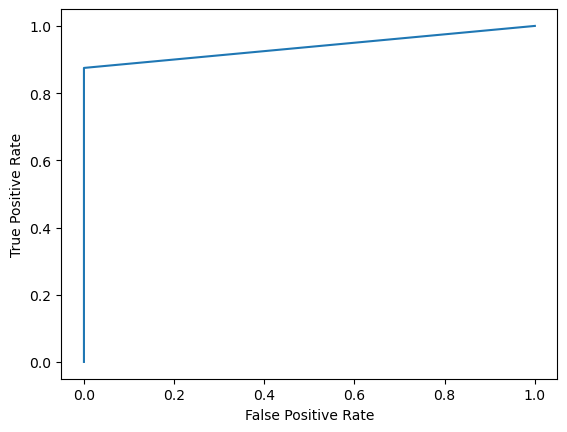

In [7]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

Accuracy:0.923
Precision:1.000
Recall:  0.875
F1-score: 0.933

Confusion Matrix:
 [[5 0]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.88      0.93         8

    accuracy                           0.92        13
   macro avg       0.92      0.94      0.92        13
weighted avg       0.94      0.92      0.92        13

F1-результаты по фолдам: [1.         1.         0.66666667 1.         0.        ]
Средний F1: 0.73


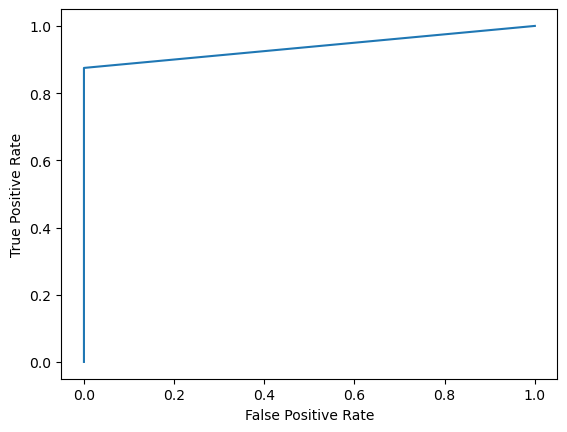

In [8]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [9]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba[:, 1]):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.923
Precision:1.000
Recall:  0.875
F1-score: 0.933
ROC-AUC:0.950

Confusion Matrix:
 [[5 0]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      1.00      0.91         5
         1.0       1.00      0.88      0.93         8

    accuracy                           0.92        13
   macro avg       0.92      0.94      0.92        13
weighted avg       0.94      0.92      0.92        13



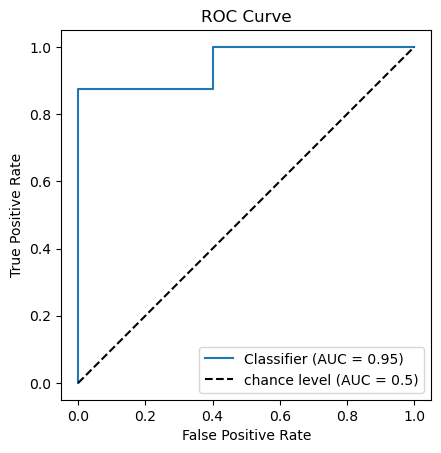

In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba[:, 1])

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

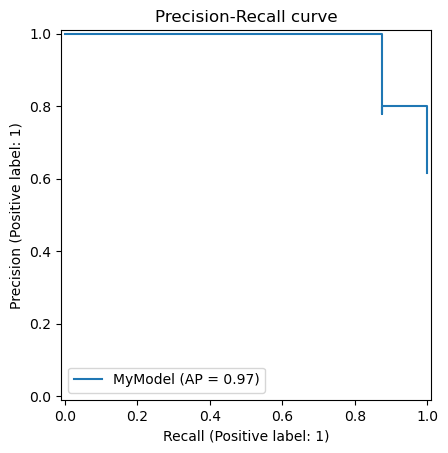

In [11]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba[:, 1], name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

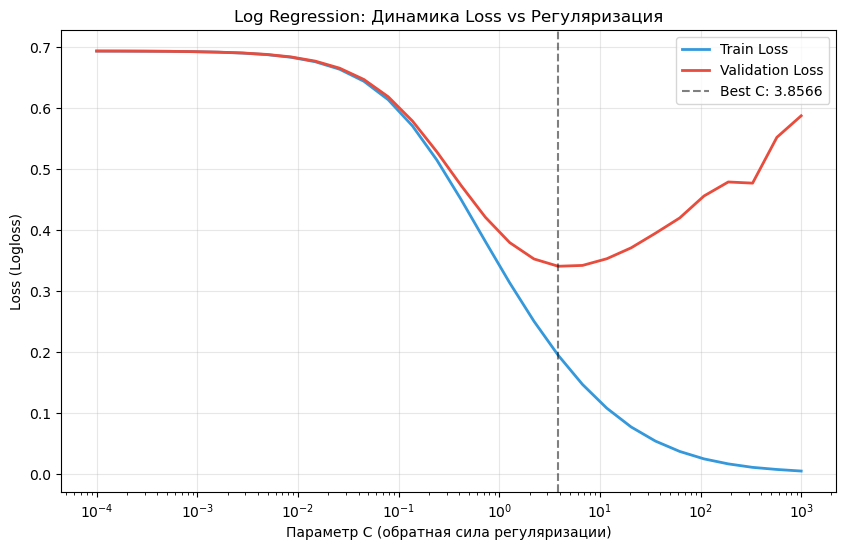

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# 1. Задаем диапазон параметра C (от сильной регуляризации до слабой)
c_range = np.logspace(-4, 3, 30)
train_losses = []
val_losses = []

for c in c_range:
    # Используем твои параметры + меняем C
    model = LogisticRegression(class_weight="balanced", C=c, max_iter=1000)
    model.fit(X_train, y_train)
    
    # Считаем вероятности для расчета Logloss
    train_proba = model.predict_proba(X_train)
    val_proba = model.predict_proba(X_test)
    
    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_test, val_proba))

# 2. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(c_range, train_losses, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(c_range, val_losses, label='Validation Loss', color='#e74c3c', linewidth=2)

# Находим точку лучшего C (минимальный Loss на валидации)
best_c = c_range[np.argmin(val_losses)]
plt.axvline(x=best_c, color='black', linestyle='--', alpha=0.5, label=f'Best C: {best_c:.4f}')

plt.xscale('log') # Шкала C всегда логарифмическая
plt.xlabel('Параметр C (обратная сила регуляризации)')
plt.ylabel('Loss (Logloss)')
plt.title('Log Regression: Динамика Loss vs Регуляризация')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
